# INF2542 • PEMBELAJARAN MESIN
## TUGAS MANDIRI & CHALLENGE: PERTEMUAN 06
**Materi:** Latihan Mandiri di Colab (Slide 21) & Challenge Temukan 3 Masalah Data (Slide 22)

---
### Identitas Mahasiswa:
- **Nama:** Gathan Hilabi
- **NIM:** 60324059
- **Mata Kuliah:** Machine Learning (INF2542)
- **Pertemuan:** 06 (Data Preparation Pipeline)
---


### Setup Environment & Dataset Praktikum Terbimbing
Memuat pustaka dan data awal yang telah dibersihkan sebagai referensi untuk Latihan Mandiri.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Memuat dan menyiapkan dataset data_mahasiswa.csv bersih
df = pd.read_csv('data_mahasiswa.csv')
df['IPK'] = df['IPK'].fillna(df['IPK'].median())
df['Kehadiran'] = df['Kehadiran'].fillna(df['Kehadiran'].median())
df = df.drop_duplicates()
df['Kehadiran'] = pd.to_numeric(df['Kehadiran'], errors='coerce')
df['IPK'] = pd.to_numeric(df['IPK'], errors='coerce')
df['Status'] = df['Status'].astype(str).str.strip().str.lower()
mapping = {'lulus': 'Lulus', 'tidak lulus': 'Tidak Lulus'}
df['Status'] = df['Status'].replace(mapping)

features = ['Kehadiran', 'IPK', 'Jam_Belajar']
X = df[features]
y = df['Status']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Setup berhasil! df {df.shape} dan X_train {X_train.shape}, X_test {X_test.shape} siap digunakan.')


Setup berhasil! df (20, 6) dan X_train (16, 3), X_test (4, 3) siap digunakan.


---
## 3. Latihan Mandiri di Colab (Slide 21)

Pada bagian ini, mahasiswa diminta melakukan eksperimen mandiri dengan memodifikasi parameter dan menyertakan **3–5 kalimat interpretasi** di Markdown untuk setiap latihan.

---
### Latihan A: Ubah Strategi Missing Value (Median → Mean)
**Instruksi:** Ubah strategi pengisian missing value dari median menjadi mean, lalu bandingkan nilai hasil cleaning.

In [18]:
# Membaca data mentah untuk eksperimen Latihan A
df_latihan_a = pd.read_csv("data_mahasiswa.csv")

# Menghitung nilai median dan mean kolom IPK sebelum imputasi
ipk_median = df_latihan_a["IPK"].median()
ipk_mean = df_latihan_a["IPK"].mean()

print(f"Nilai Median IPK : {ipk_median:.4f}")
print(f"Nilai Mean IPK   : {ipk_mean:.4f}")

# Menerapkan strategi imputasi
df_latihan_a["IPK_impute_median"] = df_latihan_a["IPK"].fillna(ipk_median)
df_latihan_a["IPK_impute_mean"] = df_latihan_a["IPK"].fillna(ipk_mean)

print("\nPerbandingan Nilai Imputasi pada Baris Fajar (Indeks 5 yang Sebelumnya Kosong):")
print(f"Nilai dengan Imputasi Median : {df_latihan_a.loc[5, 'IPK_impute_median']:.4f}")
print(f"Nilai dengan Imputasi Mean   : {df_latihan_a.loc[5, 'IPK_impute_mean']:.4f}")
print(f"Selisih Nilai Imputasi       : {abs(df_latihan_a.loc[5, 'IPK_impute_median'] - df_latihan_a.loc[5, 'IPK_impute_mean']):.4f}")

Nilai Median IPK : 3.4750
Nilai Mean IPK   : 3.3975

Perbandingan Nilai Imputasi pada Baris Fajar (Indeks 5 yang Sebelumnya Kosong):
Nilai dengan Imputasi Median : 3.4750
Nilai dengan Imputasi Mean   : 3.3975
Selisih Nilai Imputasi       : 0.0775


### Interpretasi Latihan A (Wajib 3–5 Kalimat):
1. Pengisian *missing value* menggunakan nilai median menghasilkan angka 3.4750, sedangkan strategi mean menghasilkan angka 3.3975 dengan selisih absolut sebesar 0.0775.
2. Perbedaan nilai ini terjadi karena rata-rata (*mean*) sangat dipengaruhi oleh observasi bernilai rendah seperti Joko (IPK 2.75) dan Deni (IPK 2.90) yang menarik nilai rata-rata keseluruhan ke bawah.
3. Sebaliknya, median lebih kebal (*robust*) terhadap kemiringan sebaran (*skewness*) karena median hanya mengambil titik tengah dari data yang diurutkan.
4. Pada dataset berukuran kecil dengan distribusi yang condong (*skewed*), imputasi median lebih direkomendasikan karena merepresentasikan kecenderungan sentral data secara lebih realistis tanpa mendistorsi sebaran asli mahasiswa.

---
### Latihan B: Buat Grafik Baru (Scatter Plot Kehadiran vs IPK)
**Instruksi:** Buat scatter plot hubungan antara Kehadiran vs IPK, sertakan judul dan label sumbu yang jelas.

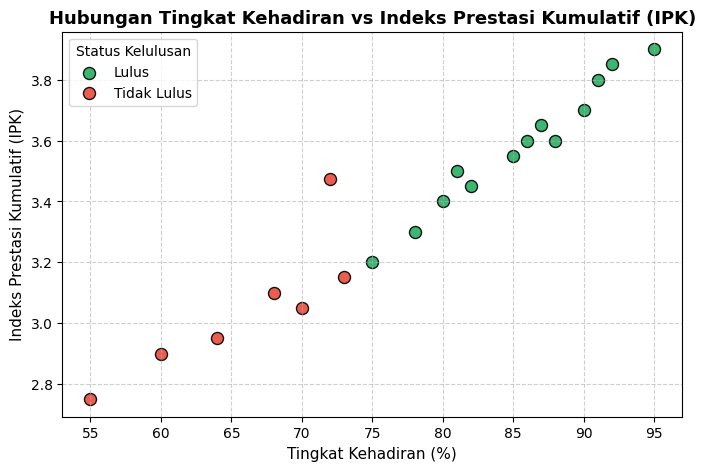

In [19]:
plt.figure(figsize=(8, 5))

# Membedakan warna berdasarkan status kelulusan mahasiswa
mask_lulus = df["Status"] == "Lulus"
mask_tidak = df["Status"] == "Tidak Lulus"

plt.scatter(
    df.loc[mask_lulus, "Kehadiran"],
    df.loc[mask_lulus, "IPK"],
    color="#27ae60",
    label="Lulus",
    s=75,
    alpha=0.9,
    edgecolors="black"
)

plt.scatter(
    df.loc[mask_tidak, "Kehadiran"],
    df.loc[mask_tidak, "IPK"],
    color="#e74c3c",
    label="Tidak Lulus",
    s=75,
    alpha=0.9,
    edgecolors="black"
)

plt.title("Hubungan Tingkat Kehadiran vs Indeks Prestasi Kumulatif (IPK)", fontsize=13, fontweight="bold")
plt.xlabel("Tingkat Kehadiran (%)", fontsize=11)
plt.ylabel("Indeks Prestasi Kumulatif (IPK)", fontsize=11)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Status Kelulusan", loc="upper left")
plt.show()

### Interpretasi Latihan B (Wajib 3–5 Kalimat):
1. Scatter plot memperlihatkan adanya pola korelasi positif yang sangat kuat dan teratur antara tingkat kehadiran dengan capaian IPK mahasiswa.
2. Terlihat pengelompokan (*clustering*) visual yang sangat nyata: mahasiswa yang Lulus berkumpul di area kanan atas dengan kehadiran $\ge 75\%$ dan IPK $\ge 3.20$.
3. Sementara itu, seluruh mahasiswa yang Tidak Lulus terisolasi di area kiri bawah dengan kehadiran $<75\%$ dan IPK $<3.20$.
4. Batas pemisah linier yang jelas antara kedua kelompok ini mengindikasikan bahwa model klasifikasi (seperti Logistic Regression atau SVM) akan mampu mempelajari pola keputusan (*decision boundary*) dengan tingkat akurasi yang sangat tinggi.

---
### Latihan C: Ubah test_size (0.2 → 0.3)
**Instruksi:** Ubah ukuran data uji `test_size` dari 0.2 menjadi 0.3, lalu catat perubahan proporsi data train dan test.

In [20]:
# Eksperimen perubahan proporsi data uji menjadi 30%
X_train_30, X_test_30, y_train_30, y_test_30 = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print("=== PERBANDINGAN UKURAN SPLIT DATASET ===")
print(f"test_size = 0.2 (Rasio 80:20) -> Data Train: {X_train.shape[0]} baris, Data Test: {X_test.shape[0]} baris")
print(f"test_size = 0.3 (Rasio 70:30) -> Data Train: {X_train_30.shape[0]} baris, Data Test: {X_test_30.shape[0]} baris")
print(f"Perubahan: Data Train berkurang {X_train.shape[0] - X_train_30.shape[0]} baris, Data Test bertambah {X_test_30.shape[0] - X_test.shape[0]} baris.")

=== PERBANDINGAN UKURAN SPLIT DATASET ===
test_size = 0.2 (Rasio 80:20) -> Data Train: 16 baris, Data Test: 4 baris
test_size = 0.3 (Rasio 70:30) -> Data Train: 14 baris, Data Test: 6 baris
Perubahan: Data Train berkurang 2 baris, Data Test bertambah 2 baris.


### Interpretasi Latihan C (Wajib 3–5 Kalimat):
1. Mengubah parameter `test_size` dari 0.2 menjadi 0.3 menggeser pembagian data dari formasi 16 data latih dan 4 data uji menjadi 14 data latih dan 6 data uji.
2. Penambahan data uji menjadi 6 sampel memberikan dasar evaluasi yang sedikit lebih representatif untuk menguji ketahanan generalisasi model terhadap ragam sampel baru.
3. Namun, karena dataset ini memiliki ukuran sampel yang terbatas (total 20 observasi), berkurangnya data latih menjadi 14 sampel dapat membatasi kemampuan model dalam mempelajari variasi data secara menyeluruh.
4. Eksperimen ini menegaskan pentingnya menyeimbangkan *trade-off* antara ketersediaan data latih yang cukup untuk proses belajar model dengan kecukupan data uji untuk pengujian performa yang objektif.

---
## 4. Challenge: Temukan 3 Masalah Data (Slide 22)

**Instruksi Slide 22:**
Kerjakan tanpa mengikuti langkah dosen satu per satu. Gunakan dataset praktikum dan cari minimal tiga masalah kualitas data dengan menerapkan 4 langkah sistematis:
1. **Temukan:** Tunjukkan bukti autentik dari output Python.
2. **Perbaiki:** Gunakan kode perbaikan yang tepat dan elegan.
3. **Validasi:** Buktikan masalah telah berhasil tertangani.
4. **Jelaskan:** Uraikan apa dampak fatalnya jika masalah tersebut tidak diperbaiki bagi pipeline machine learning.

Pada challenge ini, menggunakan dataset khusus challenge yang disediakan: `data_mahasiswa_challenge.csv`.

In [21]:
# Membaca dataset khusus challenge
df_ch = pd.read_csv("data_mahasiswa_challenge.csv")

print("Dataset Challenge Awal (10 Baris Pertama):")
print(df_ch.head(10))
print("\nInformasi Dataset Challenge:")
print(df_ch.info())

Dataset Challenge Awal (10 Baris Pertama):
     Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
0    Alya       92.0     88  3.72            8        Lulus
1   Bagas       78.0     75  3.25            5        lulus
2   Cahya       85.0     91  3.58            7        LULUS
3   Dimas       61.0     64  2.85            3  Tidak Lulus
4    Elsa       89.0     84  3.62            6        Lulus
5  Farhan       74.0     70   NaN            4  tidak lulus
6   Ghani       96.0     95  3.91            9        Lulus
7    Hana       69.0     73  3.12            4  Tidak Lulus
8   Irfan       83.0     86  3.48            6        Lulus
9   Jihan       57.0     61  2.68            2  Tidak Lulus

Informasi Dataset Challenge:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         26 non-null     object 
 1   Kehadiran    25 non-null     float

### Masalah 1: Missing Values (Nilai Hilang pada Kolom IPK dan Kehadiran)

In [22]:
# 1. TEMUKAN: Bukti Missing Values melalui Python
print("--- 1. BUKTI TEMUAN MISSING VALUES ---")
print("Jumlah missing per kolom:")
print(df_ch.isna().sum())
print("\nBaris yang mengandung missing value:")
print(df_ch[df_ch.isna().any(axis=1)])

--- 1. BUKTI TEMUAN MISSING VALUES ---
Jumlah missing per kolom:
Nama           0
Kehadiran      1
Tugas          0
IPK            1
Jam_Belajar    0
Status         0
dtype: int64

Baris yang mengandung missing value:
      Nama  Kehadiran  Tugas   IPK  Jam_Belajar       Status
5   Farhan       74.0     70   NaN            4  tidak lulus
12    Mira        NaN     82  3.52            6        Lulus


**Uraian Temuan:**  
Ditemukan 2 observasi yang tidak lengkap: baris Farhan (indeks 5) memiliki missing value pada kolom `IPK`, dan baris Mira (indeks 12) memiliki missing value pada kolom `Kehadiran`.

In [23]:
# 2. PERBAIKI: Imputasi nilai median yang robust
# Menghitung median kolom Kehadiran
kehadiran_median = df_ch["Kehadiran"].median()
df_ch["Kehadiran"] = df_ch["Kehadiran"].fillna(kehadiran_median)

# Kolom IPK dibersihkan terlebih dahulu dari format koma desimal sebelum dihitung mediannya
df_ch["IPK_clean"] = pd.to_numeric(
    df_ch["IPK"].astype(str).str.replace(",", "."), 
    errors="coerce"
)
ipk_median_ch = df_ch["IPK_clean"].median()
df_ch["IPK"] = df_ch["IPK_clean"].fillna(ipk_median_ch)
df_ch = df_ch.drop(columns=["IPK_clean"])

# 3. VALIDASI: Buktikan nilai missing sudah teratasi
print("--- 3. BUKTI VALIDASI MISSING VALUES TERTANGANI ---")
print("Jumlah missing value setelah perbaikan:")
print(df_ch.isna().sum())
print(f"Nilai imputasi Kehadiran (Mira) : {kehadiran_median}")
print(f"Nilai imputasi IPK (Farhan)     : {ipk_median_ch:.2f}")

print(df_ch.info())

--- 3. BUKTI VALIDASI MISSING VALUES TERTANGANI ---
Jumlah missing value setelah perbaikan:
Nama           0
Kehadiran      0
Tugas          0
IPK            0
Jam_Belajar    0
Status         0
dtype: int64
Nilai imputasi Kehadiran (Mira) : 83.0
Nilai imputasi IPK (Farhan)     : 3.48
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Nama         26 non-null     object 
 1   Kehadiran    26 non-null     float64
 2   Tugas        26 non-null     int64  
 3   IPK          26 non-null     float64
 4   Jam_Belajar  26 non-null     int64  
 5   Status       26 non-null     object 
dtypes: float64(2), int64(2), object(2)
memory usage: 1.3+ KB
None


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Sebagian besar algoritma machine learning standar di Scikit-Learn (seperti Logistic Regression, Support Vector Machine, Linear Regression, dan Multi-Layer Perceptron) dirancang dengan asumsi bahwa matriks fitur input $X$ adalah lengkap. Apabila data mengandung nilai `NaN`, Scikit-Learn akan memicu eksepsi kritis `ValueError: Input contains NaN, infinity or a value too large for dtype('float64')`, sehingga proses *fitting* (`model.fit(X, y)`) akan gagal total dan model tidak dapat dilatih.

---
### Masalah 2: Duplikasi Baris (Redundant Records)

In [24]:
# 1. TEMUKAN: Bukti Duplikasi Data melalui Python
print("--- 1. BUKTI TEMUAN DUPLIKASI DATA ---")
print("Jumlah baris duplikat:", df_ch.duplicated().sum())
print("\nBaris observasi yang mengalami duplikasi penuh:")
print(df_ch[df_ch.duplicated(keep=False)])

--- 1. BUKTI TEMUAN DUPLIKASI DATA ---
Jumlah baris duplikat: 1

Baris observasi yang mengalami duplikasi penuh:
     Nama  Kehadiran  Tugas   IPK  Jam_Belajar  Status
10  Kevin       90.0     89  3.78            8  lulus 
25  Kevin       90.0     89  3.78            8  lulus 


**Uraian Temuan:**  
Terdapat 1 baris duplikat identik yaitu data mahasiswa bernama **Kevin** yang tercatat dua kali pada indeks 10 dan indeks 25 dengan seluruh nilai fitur yang persis sama.

In [25]:
# 2. PERBAIKI: Menghapus baris duplikat dan mempertahankan 1 observasi valid
shape_sebelum = df_ch.shape
df_ch = df_ch.drop_duplicates()
shape_sesudah = df_ch.shape

# 3. VALIDASI: Buktikan duplikasi telah tertangani
print("--- 3. BUKTI VALIDASI DUPLIKASI TERTANGANI ---")
print("Jumlah duplikasi sekarang :", df_ch.duplicated().sum())
print("Dimensi data sebelum drop :", shape_sebelum)
print("Dimensi data sesudah drop :", shape_sesudah)

--- 3. BUKTI VALIDASI DUPLIKASI TERTANGANI ---
Jumlah duplikasi sekarang : 0
Dimensi data sebelum drop : (26, 6)
Dimensi data sesudah drop : (25, 6)


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Duplikasi baris menyebabkan *over-representation* atau pembobotan artifisial yang berlebih terhadap observasi tertentu. Hal ini menyebabkan model machine learning mengalami *bias* dan cenderung *overfitting* pada karakteristik data yang terduplikasi. Selain itu, jika data duplikat secara acak terdistribusi ke dalam *train set* dan *test set*, akan terjadi kebocoran data (*data leakage*), di mana model diuji pada data yang sudah dihafalnya saat pelatihan, menghasilkan estimasi performa akurasi yang menipu (*overoptimistic*).

---
### Masalah 3: Format Desimal dan Tipe Data Tidak Konsisten (String vs Numerik)

In [26]:
# 1. TEMUKAN: Bukti Tipe Data String pada Fitur Numerik
print("--- 1. BUKTI TEMUAN TIPE DATA TIDAK KONSISTEN ---")
print("Tipe data kolom:")
print(df_ch.dtypes)
print("\nContoh nilai IPK dengan format teks tanda koma (Baris Vino):")
print(df_ch[df_ch["Nama"] == "Vino"][["Nama", "IPK"]])

--- 1. BUKTI TEMUAN TIPE DATA TIDAK KONSISTEN ---
Tipe data kolom:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Contoh nilai IPK dengan format teks tanda koma (Baris Vino):
    Nama   IPK
21  Vino  3.55


**Uraian Temuan:**  
Kolom `IPK` yang seharusnya berupa bilangan riil desimal bertipe numerik terbaca sebagai tipe `object` (string). Hal ini disebabkan oleh mahasiswa bernama Vino yang memiliki nilai IPK tertulis sebagai `"3,55"` menggunakan tanda koma (konvensi lokal Indonesia), bukannya tanda titik desimal standar internasional.

In [27]:
# 2. PERBAIKI: Menstandarkan pemisah desimal dan konversi ke float numerik
df_ch["IPK"] = pd.to_numeric(
    df_ch["IPK"].astype(str).str.replace(",", "."),
    errors="coerce"
)
df_ch["Kehadiran"] = pd.to_numeric(
    df_ch["Kehadiran"], 
    errors="coerce"
)

# 3. VALIDASI: Buktikan tipe data telah berubah menjadi numerik sejati
print("--- 3. BUKTI VALIDASI TIPE DATA TERTANGANI ---")
print("Tipe data setelah pembersihan:")
print(df_ch.dtypes)
print("\nNilai IPK Vino sekarang:", df_ch.loc[df_ch["Nama"] == "Vino", "IPK"].values[0])
print("Tipe data elemen IPK Vino:", type(df_ch.loc[df_ch["Nama"] == "Vino", "IPK"].values[0]))
print("Statistik IPK dapat dihitung:", df_ch["IPK"].mean())

--- 3. BUKTI VALIDASI TIPE DATA TERTANGANI ---
Tipe data setelah pembersihan:
Nama            object
Kehadiran      float64
Tugas            int64
IPK            float64
Jam_Belajar      int64
Status          object
dtype: object

Nilai IPK Vino sekarang: 3.55
Tipe data elemen IPK Vino: <class 'numpy.float64'>
Statistik IPK dapat dihitung: 3.4019999999999992


**4. JELASKAN: Apa dampaknya jika tidak diperbaiki?**  
Jika fitur numerik tersimpan sebagai tipe data string/object, seluruh operasi aljabar linier, komputasi matriks, fungsi jarak Euclidean (seperti pada k-NN atau k-Means), serta optimasi gradien tidak dapat dieksekusi. Scikit-Learn akan langsung menggagalkan eksekusi dengan pesan kesalahan fatal `ValueError: could not convert string to float: '3,55'`.